데이터 및 결과 파일 로딩 중...
좌표 차원 수: 3
ARI = 0.5769
✅ 그래프가 'hepta_plaintext_bmodel_result_eps1.0_min4_plot.png' 로 저장되었습니다.


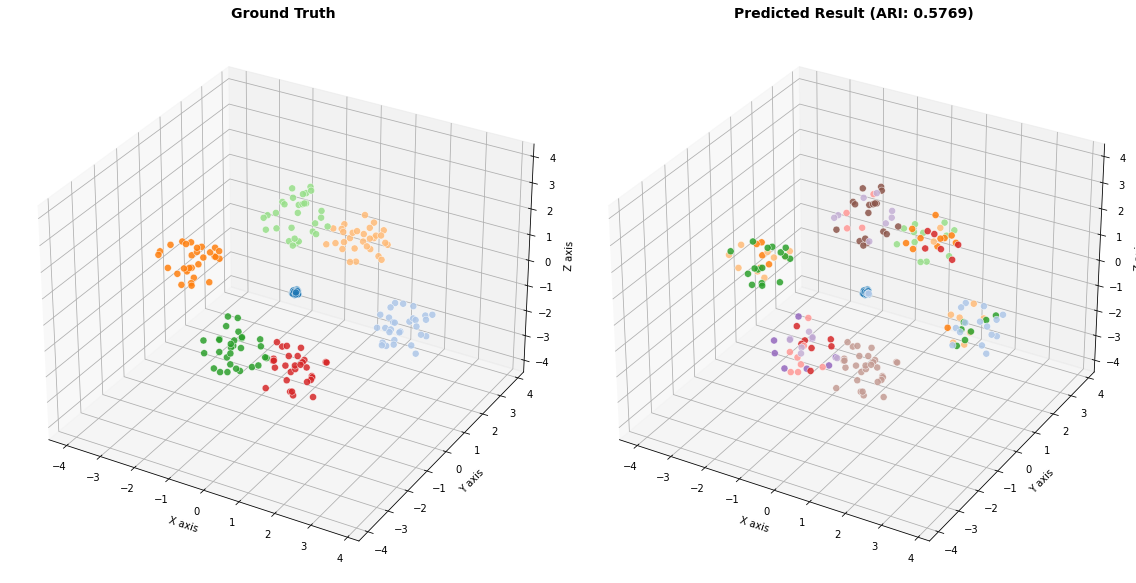

In [4]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import adjusted_rand_score


# ---------------------------------------------------------
# 1. 파일 경로 설정 (사용자 환경에 맞게 수정하세요)
# ---------------------------------------------------------
ARFF_PATH = "/home/junhyung/study/Data_Analysis_with_CKKS/Cluster/DBSCAN_CKKS/desilo/dataset/Other_cluster/hepta.arff"
CSV_PATH = "/home/junhyung/study/Data_Analysis_with_CKKS/Cluster/DBSCAN_CKKS/desilo/hepta_plaintext_bmodel_result_eps1.0_min4.csv"


def load_arff_to_pts(filepath):
    pts = []
    data_section = False

    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith('%'):
                continue
            if line.lower().startswith('@data'):
                data_section = True
                continue
            if data_section:
                line = line.replace('\t', ' ').replace(',', ' ')
                values = line.split()
                if len(values) < 2:
                    continue
                row = [float(v) for v in values[:-1]]
                pts.append(row)

    return np.array(pts, dtype=np.float64)


def pick_first_existing_column(df, candidates, column_role):
    for col in candidates:
        if col in df.columns:
            return col
    raise ValueError(
        f"{column_role} 컬럼을 찾지 못했습니다. "
        f"현재 CSV 컬럼: {list(df.columns)}"
    )


def label_to_color(label, cmap, valid_labels):
    if label == -1:
        return 'black'
    idx = valid_labels.index(label) % cmap.N
    return cmap(idx)


def plot_clusters_2d(ax, X, Y, labels, title, cmap):
    unique_labels = sorted(np.unique(labels).tolist())
    valid_labels = [x for x in unique_labels if x != -1]

    for label in unique_labels:
        idx = labels == label
        if label == -1:
            ax.scatter(
                X[idx], Y[idx],
                c='black',
                marker='x',
                s=30,
                label='Noise(-1)'
            )
        else:
            color = label_to_color(label, cmap, valid_labels)
            ax.scatter(
                X[idx], Y[idx],
                c=[color],
                s=45,
                alpha=0.85,
                edgecolors='white',
                linewidths=0.5,
                label=f'Cluster {label}'
            )

    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel('X axis')
    ax.set_ylabel('Y axis')


def plot_clusters_3d(ax, X, Y, Z, labels, title, cmap):
    unique_labels = sorted(np.unique(labels).tolist())
    valid_labels = [x for x in unique_labels if x != -1]

    for label in unique_labels:
        idx = labels == label
        if label == -1:
            ax.scatter(
                X[idx], Y[idx], Z[idx],
                c='black',
                marker='x',
                s=25,
                label='Noise(-1)'
            )
        else:
            color = label_to_color(label, cmap, valid_labels)
            ax.scatter(
                X[idx], Y[idx], Z[idx],
                c=[color],
                s=50,
                alpha=0.85,
                edgecolors='white',
                linewidths=0.5,
                label=f'Cluster {label}'
            )

    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel('X axis')
    ax.set_ylabel('Y axis')
    ax.set_zlabel('Z axis')


def main():
    print("데이터 및 결과 파일 로딩 중...")

    if not os.path.exists(ARFF_PATH):
        raise FileNotFoundError(f"ARFF 파일을 찾을 수 없습니다: {ARFF_PATH}")
    if not os.path.exists(CSV_PATH):
        raise FileNotFoundError(f"CSV 파일을 찾을 수 없습니다: {CSV_PATH}")

    # 2. 데이터 로드
    pts = load_arff_to_pts(ARFF_PATH)
    df = pd.read_csv(CSV_PATH)

    if len(pts) != len(df):
        print("🚨 경고: ARFF 데이터 개수와 CSV 결과 개수가 다릅니다!")
        print(f"  - ARFF 점 개수: {len(pts)}")
        print(f"  - CSV 행 개수: {len(df)}")
        return

    dimension = pts.shape[1]
    print(f"좌표 차원 수: {dimension}")

    # ---------------------------------------------------------
    # 3. CSV 컬럼 자동 탐색
    # ---------------------------------------------------------
    true_col = pick_first_existing_column(
        df,
        ["True_Class", "True_Label", "Ground_Truth", "Label"],
        "정답"
    )

    pred_col = pick_first_existing_column(
        df,
        [
            "PT_BModel_Cluster",
            "Plaintext_Label",
            "Rounded_FHE_Label",
            "FHE_Cluster",
            "PT_Cluster",
        ],
        "예측 라벨"
    )

    true_labels = df[true_col].values
    pred_labels = df[pred_col].values

    ari = adjusted_rand_score(true_labels, pred_labels)
    print(f"ARI = {ari:.4f}")

    # ---------------------------------------------------------
    # 4. 시각화 설정
    # ---------------------------------------------------------
    cmap = plt.get_cmap('tab20')

    if dimension == 2:
        X = pts[:, 0]
        Y = pts[:, 1]

        fig = plt.figure(figsize=(14, 6))

        ax1 = fig.add_subplot(121)
        plot_clusters_2d(ax1, X, Y, true_labels, "Ground Truth", cmap)

        ax2 = fig.add_subplot(122)
        plot_clusters_2d(ax2, X, Y, pred_labels, f"Predicted Result (ARI: {ari:.4f})", cmap)

    elif dimension == 3:
        X = pts[:, 0]
        Y = pts[:, 1]
        Z = pts[:, 2]

        fig = plt.figure(figsize=(16, 8))

        ax1 = fig.add_subplot(121, projection='3d')
        plot_clusters_3d(ax1, X, Y, Z, true_labels, "Ground Truth", cmap)

        ax2 = fig.add_subplot(122, projection='3d')
        plot_clusters_3d(ax2, X, Y, Z, pred_labels, f"Predicted Result (ARI: {ari:.4f})", cmap)

    else:
        raise ValueError(
            f"현재 시각화는 2차원 또는 3차원만 지원합니다. 현재 차원: {dimension}"
        )

    # ---------------------------------------------------------
    # 5. 저장 및 출력
    # ---------------------------------------------------------
    plt.tight_layout()

    base_name = os.path.splitext(os.path.basename(CSV_PATH))[0]
    save_filename = f"{base_name}_plot.png"

    plt.savefig(save_filename, dpi=300, bbox_inches='tight')
    print(f"✅ 그래프가 '{save_filename}' 로 저장되었습니다.")

    plt.show()


if __name__ == '__main__':
    main()